In [1]:
import pyxdf

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
file_path=r"C:\Users\abolhassni\Desktop\TU Darmstadt\Term3\ANSYMB\LSL\imu_motion_capture_analysis\data\raw\introduction_to_xdf\introduction_to_xdf_files.xdf"

streams, header=pyxdf.load_xdf(file_path)

Stream 10: Calculated effective sampling rate 0.0000 Hz is different from specified rate 100.0000 Hz.
Stream 3: Calculated effective sampling rate 0.0000 Hz is different from specified rate 100.0000 Hz.
Stream 8: Calculated effective sampling rate 0.0000 Hz is different from specified rate 100.0000 Hz.
Stream 5: Calculated effective sampling rate 0.0000 Hz is different from specified rate 100.0000 Hz.
Stream 12: Calculated effective sampling rate 0.0000 Hz is different from specified rate 100.0000 Hz.
Stream 11: Calculated effective sampling rate 0.0000 Hz is different from specified rate 100.0000 Hz.


In [6]:
for i, stream in enumerate(streams):
    print(i, stream.keys())

0 dict_keys(['info', 'footer', 'time_series', 'time_stamps', 'clock_times', 'clock_values'])
1 dict_keys(['info', 'footer', 'time_series', 'time_stamps', 'clock_times', 'clock_values'])
2 dict_keys(['info', 'footer', 'time_series', 'time_stamps', 'clock_times', 'clock_values'])
3 dict_keys(['info', 'footer', 'time_series', 'time_stamps', 'clock_times', 'clock_values'])
4 dict_keys(['info', 'footer', 'time_series', 'time_stamps', 'clock_times', 'clock_values'])
5 dict_keys(['info', 'footer', 'time_series', 'time_stamps', 'clock_times', 'clock_values'])
6 dict_keys(['info', 'footer', 'time_series', 'time_stamps', 'clock_times', 'clock_values'])
7 dict_keys(['info', 'footer', 'time_series', 'time_stamps', 'clock_times', 'clock_values'])
8 dict_keys(['info', 'footer', 'time_series', 'time_stamps', 'clock_times', 'clock_values'])
9 dict_keys(['info', 'footer', 'time_series', 'time_stamps', 'clock_times', 'clock_values'])
10 dict_keys(['info', 'footer', 'time_series', 'time_stamps', 'clock_t

In [ ]:
streams[0]["info"]["name"]

['Xsens_MTw2_00B4D0C8']

In [ ]:
streams[1]["info"]["name"]

In [13]:
names = []

for i, stream in enumerate(streams):
    sensor_name = stream["info"]["name"][0]
    names.append(sensor_name)

names

['Xsens_MTw2_00B4D0C8',
 'Xsens_MTw2_00B4D0C4',
 'Xsens_MTw2_00B4D0BE',
 'Xsens_MTw2_00B4D0BF',
 'Xsens_MTw2_00B4D0C5',
 'Xsens_MTw2_00B4D0C4',
 'Xsens_MTw2_00B4D0C8',
 'Xsens_MTw2_00B4D0C5',
 'Xsens_MTw2_00B4D0BE',
 'Xsens_MTw2_00B4D0D0',
 'Xsens_MTw2_00B4D0D0',
 'Xsens_MTw2_00B4D0BF']

In [15]:
for i, stream in enumerate(streams):
    name = stream["info"]["name"][0]
    
    data = stream["time_series"]
    time = stream["time_stamps"]
    
    print("Index:", i)
    print("Name:", name)
    print("Data shape:", data.shape)
    print("Time shape:", time.shape)
    
    if len(time) == 0:
        print("Status: EMPTY time_stamps")
    else:
        duration = time[-1] - time[0]
        fs_estimated = data.shape[0] / duration
        
        print("Duration:", duration)
        print("Estimated sampling rate:", fs_estimated)
    
    print("----------------------------")

Index: 0
Name: Xsens_MTw2_00B4D0C8
Data shape: (1396, 12)
Time shape: (1396,)
Duration: 14.021510328253498
Estimated sampling rate: 99.56131453164818
----------------------------
Index: 1
Name: Xsens_MTw2_00B4D0C4
Data shape: (12, 0)
Time shape: (0,)
Status: EMPTY time_stamps
----------------------------
Index: 2
Name: Xsens_MTw2_00B4D0BE
Data shape: (1397, 12)
Time shape: (1397,)
Duration: 14.044492712826468
Estimated sampling rate: 99.46959484867378
----------------------------
Index: 3
Name: Xsens_MTw2_00B4D0BF
Data shape: (12, 0)
Time shape: (0,)
Status: EMPTY time_stamps
----------------------------
Index: 4
Name: Xsens_MTw2_00B4D0C5
Data shape: (1397, 12)
Time shape: (1397,)
Duration: 14.043825463799294
Estimated sampling rate: 99.47432083950635
----------------------------
Index: 5
Name: Xsens_MTw2_00B4D0C4
Data shape: (1396, 12)
Time shape: (1396,)
Duration: 14.0519842474896
Estimated sampling rate: 99.34540029458094
----------------------------
Index: 6
Name: Xsens_MTw2_00B4D0

In [17]:
valid_streams = []

for i, stream in enumerate(streams):
    name = stream["info"]["name"][0]
    data = stream["time_series"]
    time = stream["time_stamps"]
    
    if len(time) == 0:
        print("Skipped empty stream:", i, name)
        continue
    
    if data.shape[0] == 0:
        print("Skipped empty data:", i, name)
        continue
    
    valid_streams.append(stream)

print("Number of valid streams:", len(valid_streams))

valid_streams

Skipped empty stream: 1 Xsens_MTw2_00B4D0C4
Skipped empty stream: 3 Xsens_MTw2_00B4D0BF
Skipped empty stream: 6 Xsens_MTw2_00B4D0C8
Skipped empty stream: 7 Xsens_MTw2_00B4D0C5
Skipped empty stream: 8 Xsens_MTw2_00B4D0BE
Skipped empty stream: 9 Xsens_MTw2_00B4D0D0
Number of valid streams: 6


[{'info': defaultdict(list,
              {'name': ['Xsens_MTw2_00B4D0C8'],
               'type': ['IMU'],
               'channel_count': ['12'],
               'channel_format': ['float32'],
               'source_id': ['Xsens_MTw2_00B4D0C8'],
               'nominal_srate': ['100.0000000000000'],
               'version': ['1.100000000000000'],
               'created_at': ['229472.9026658000'],
               'uid': ['11d46b6c-28e1-4dfa-acf6-db3469db7295'],
               'session_id': ['default'],
               'hostname': ['DESKTOP-TNI5205'],
               'v4address': [None],
               'v4data_port': ['16579'],
               'v4service_port': ['16579'],
               'v6address': [None],
               'v6data_port': ['16579'],
               'v6service_port': ['16579'],
               'desc': [defaultdict(list,
                            {'channels': [defaultdict(list,
                                          {'channel': [defaultdict(list,
                          

In [18]:
sensor_dfs = {}

for stream in valid_streams:
    sensor_name = stream["info"]["name"][0]
    
    data = stream["time_series"]
    time = stream["time_stamps"]
    
    time_insert = time - time[0]
    
    channels = stream["info"]["desc"][0]["channels"][0]["channel"]
    column_names = [ch["label"][0] for ch in channels]
    
    df = pd.DataFrame(data, columns=column_names)
    
    df.insert(0, "time_stamp", time)
    df.insert(1, "time_insert", time_insert)
    
    sensor_dfs[sensor_name] = df

In [19]:
sensor_dfs.keys()

dict_keys(['Xsens_MTw2_00B4D0C8', 'Xsens_MTw2_00B4D0BE', 'Xsens_MTw2_00B4D0C5', 'Xsens_MTw2_00B4D0C4', 'Xsens_MTw2_00B4D0D0', 'Xsens_MTw2_00B4D0BF'])

In [20]:
sensor_dfs["Xsens_MTw2_00B4D0C8"].head()

,time_stamp,time_insert,qw,qx,qy,qz,ax,ay,az,gx,gy,gz,packet_counter,sample_time_fine
0,229501.472544,0.000000,0.099020,0.005810,-0.002649,-0.995065,-0.090631,0.075291,9.776200,-0.008962,0.006068,-0.002955,12303.0,0.0
1,229501.482596,0.010051,0.099021,0.005805,-0.002610,-0.995065,-0.083169,0.051323,9.751882,-0.006871,0.003363,-0.001430,12304.0,0.0
2,229501.492647,0.020103,0.099018,0.005803,-0.002555,-0.995066,-0.091469,0.073681,9.776204,-0.010151,0.004301,-0.001368,12305.0,0.0
3,229501.502698,0.030154,0.099004,0.005797,-0.002484,-0.995067,-0.101624,0.094862,9.751747,-0.013208,0.003712,-0.004408,12306.0,0.0
4,229501.512749,0.040205,0.098985,0.005792,-0.002421,-0.995069,-0.115895,0.062052,9.752830,-0.011709,0.003993,-0.004440,12307.0,0.0


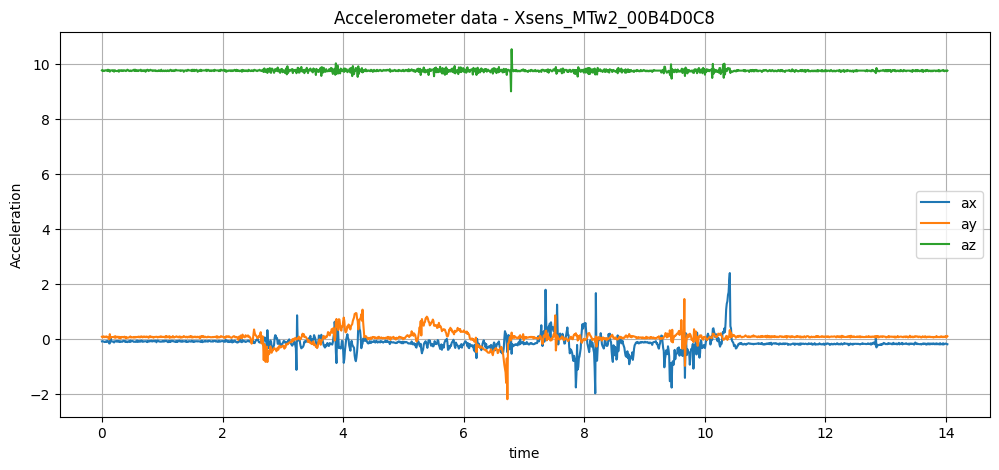

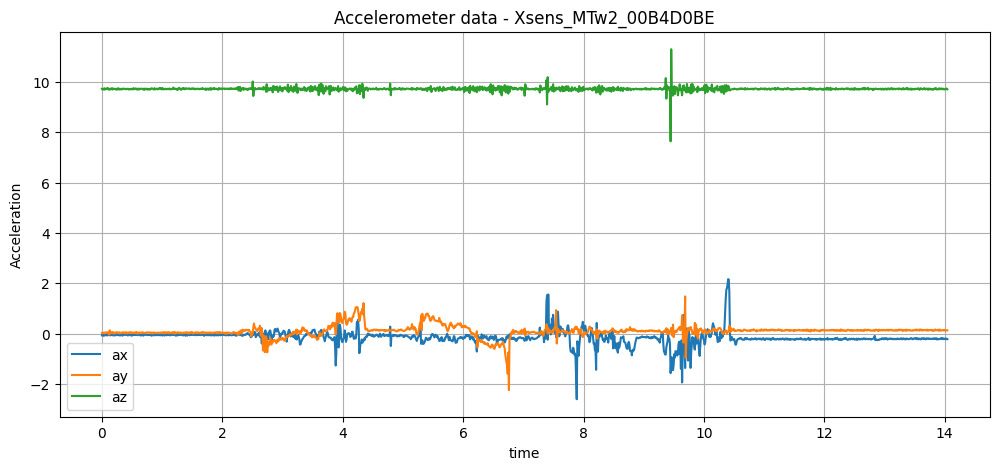

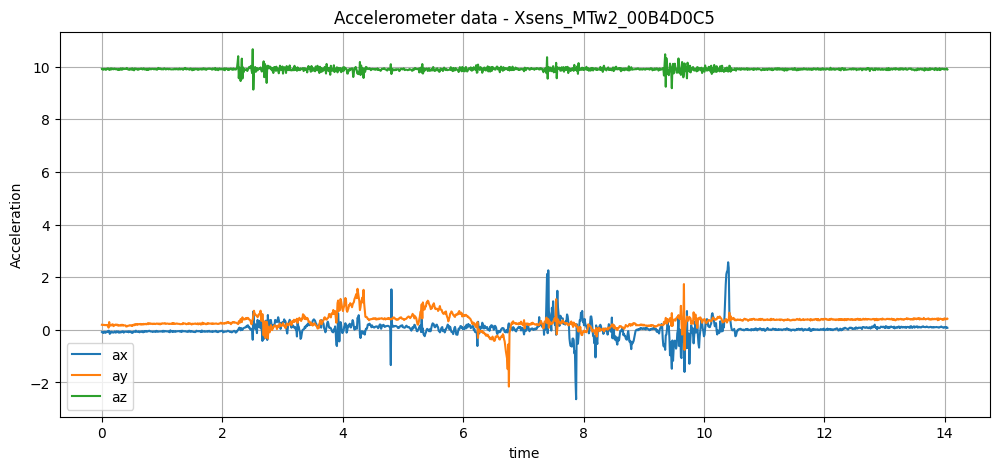

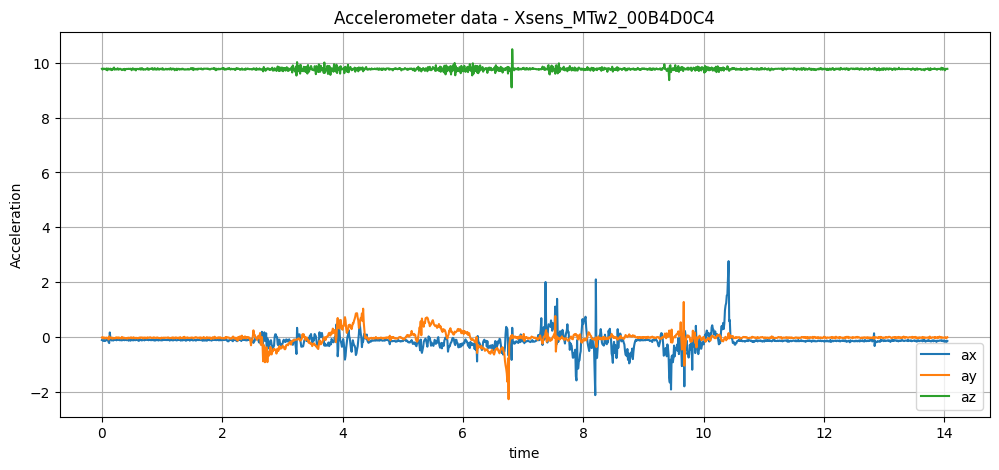

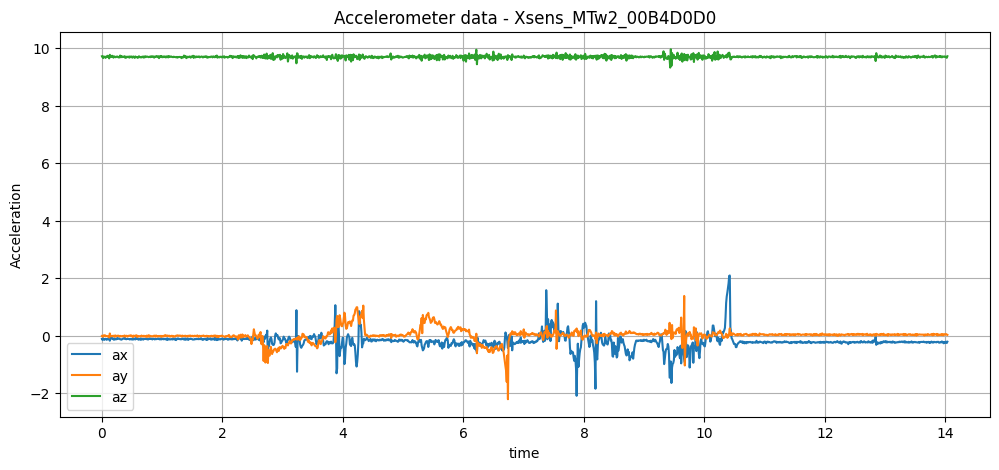

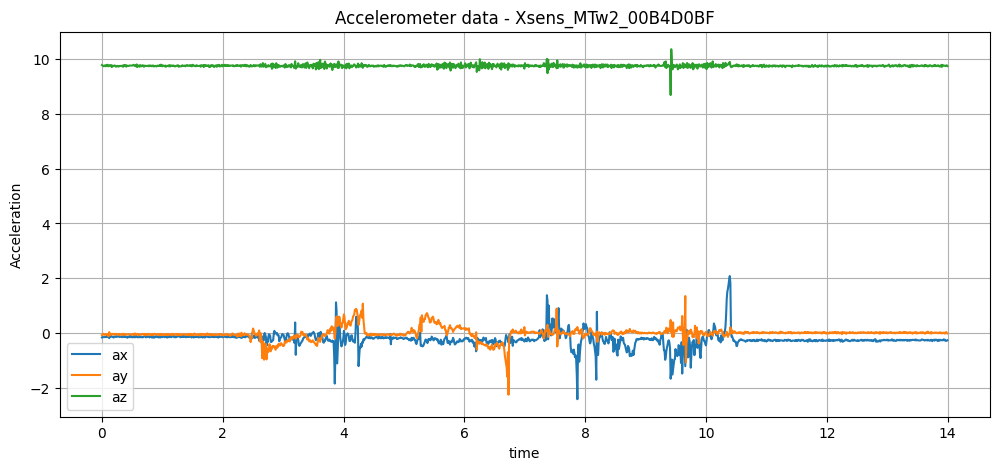

In [21]:
for sensor_name, df in sensor_dfs.items():
    
    t = df["time_insert"]
    
    plt.figure(figsize=(12, 5))

    plt.plot(t, df["ax"], label="ax")
    plt.plot(t, df["ay"], label="ay")
    plt.plot(t, df["az"], label="az")

    plt.xlabel("time")
    plt.ylabel("Acceleration")
    plt.title(f"Accelerometer data - {sensor_name}")

    plt.legend()
    plt.grid(True)
    plt.show()

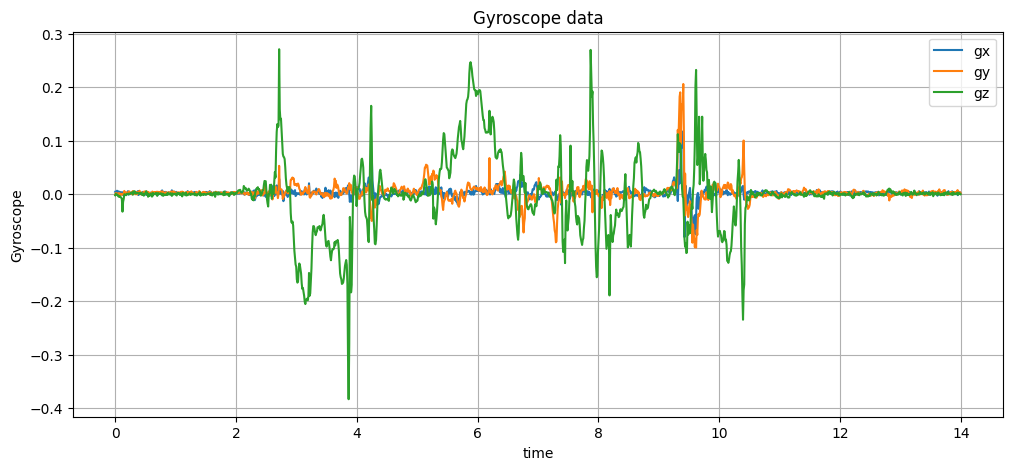

In [23]:
t=df["time_insert"]
plt.figure(figsize=(12,5))

plt.plot(t, df["gx"], label="gx")
plt.plot(t, df["gy"], label="gy")
plt.plot(t, df["gz"], label="gz")

plt.xlabel("time")
plt.ylabel("Gyroscope")
plt.title("Gyroscope data")

plt.legend()
plt.grid(True)
plt.show()

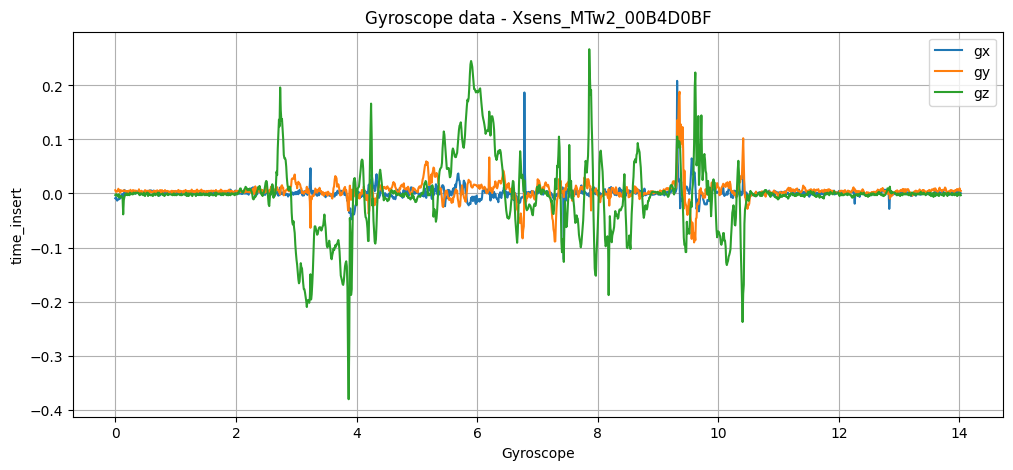

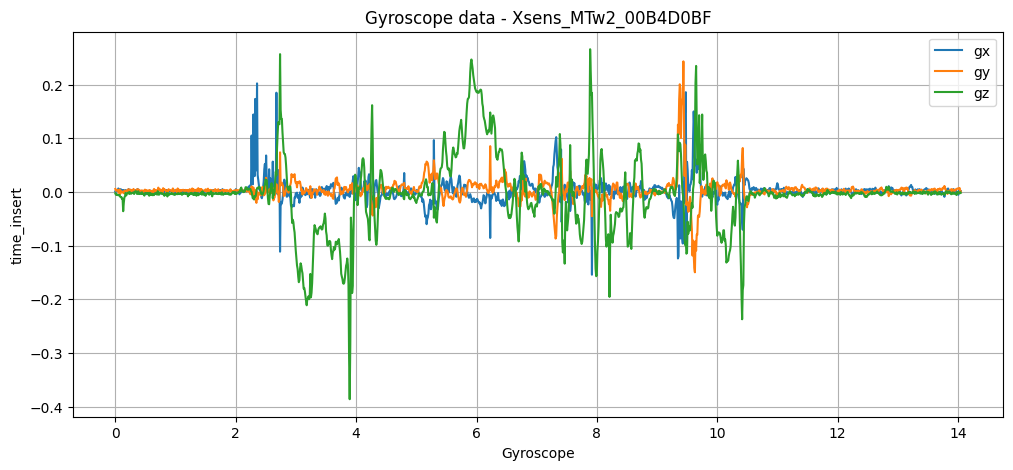

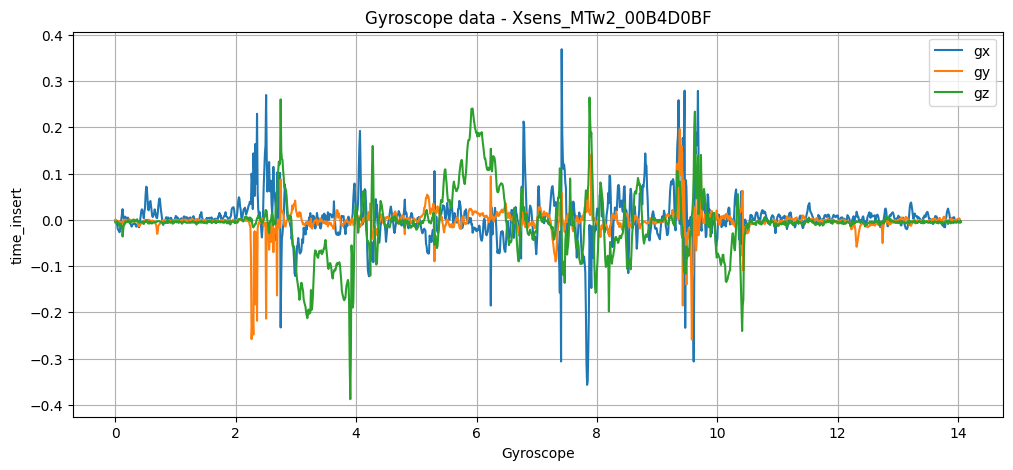

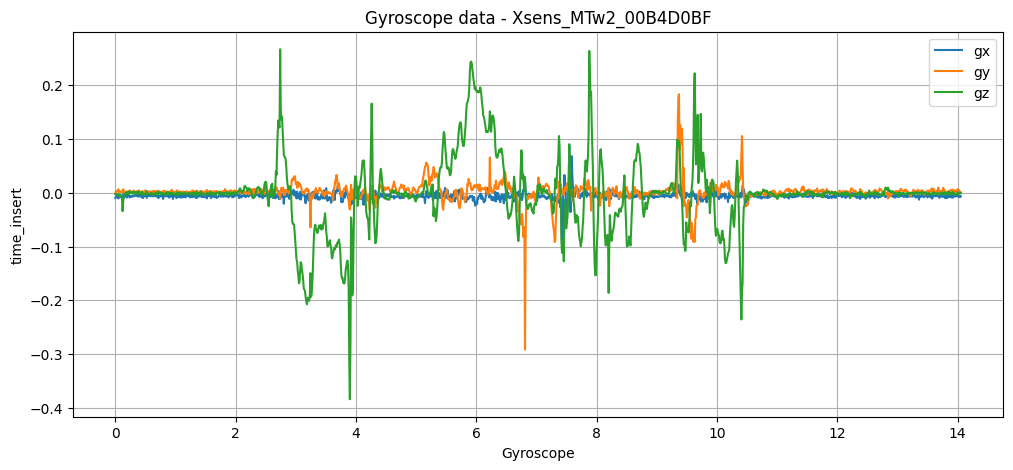

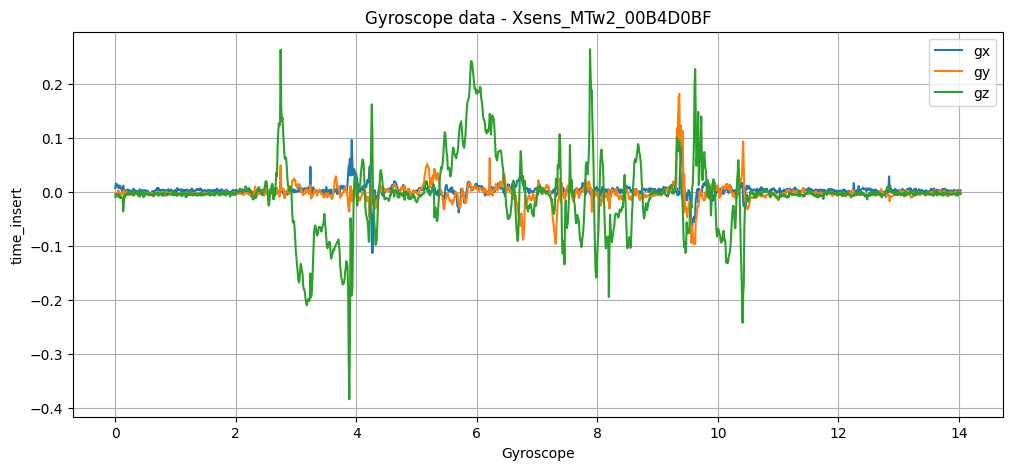

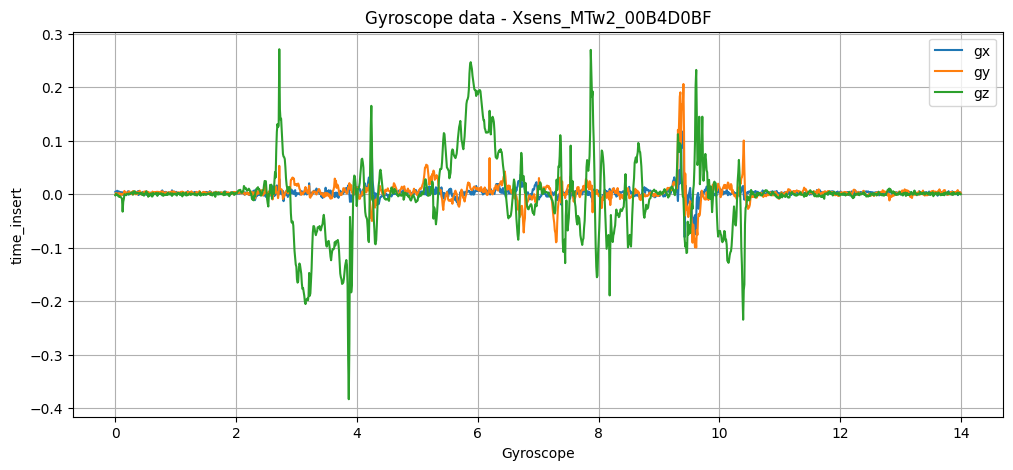

In [27]:
for sensor, df in sensor_dfs.items():

    t=df["time_insert"]

    plt.figure(figsize=(12,5))
    plt.plot(t, df["gx"], label="gx")
    plt.plot(t, df["gy"], label="gy")
    plt.plot(t, df["gz"], label="gz")


    plt.xlabel("Gyroscope")
    plt.ylabel("time_insert")
    plt.title(f"Gyroscope data - {sensor_name}")


    plt.legend()
    plt.grid(True)
    plt.show()


